Unikalne wartości w kolumnie 'Label':
[0 1]
Label
0    413933
1    288785
Name: count, dtype: int64
Epoch 1/5
17568/17568 ━━━━━━━━━━━━━━━━━━━━ 11s 593us/step - Precision: 0.9910 - Recall: 0.9815 - accuracy: 0.9888 - loss: 0.0331 - val_Precision: 0.9992 - val_Recall: 0.9918 - val_accuracy: 0.9963 - val_loss: 0.0124
Epoch 2/5
17568/17568 ━━━━━━━━━━━━━━━━━━━━ 10s 566us/step - Precision: 0.9980 - Recall: 0.9928 - accuracy: 0.9962 - loss: 0.0123 - val_Precision: 0.9988 - val_Recall: 0.9954 - val_accuracy: 0.9976 - val_loss: 0.0075
Epoch 3/5
17568/17568 ━━━━━━━━━━━━━━━━━━━━ 10s 561us/step - Precision: 0.9986 - Recall: 0.9933 - accuracy: 0.9967 - loss: 0.0109 - val_Precision: 0.9926 - val_Recall: 0.9953 - val_accuracy: 0.9950 - val_loss: 0.0132
Epoch 4/5
17568/17568 ━━━━━━━━━━━━━━━━━━━━ 10s 565us/step - Precision: 0.9986 - Recall: 0.9934 - accuracy: 0.9967 - loss: 0.0104 - val_Precision: 0.9992 - val_Recall: 0.9877 - val_accuracy: 0.9946 - val_loss: 0.0175
Epoch 5/5
17568/17568 ━━━━━━━━━━━━━━

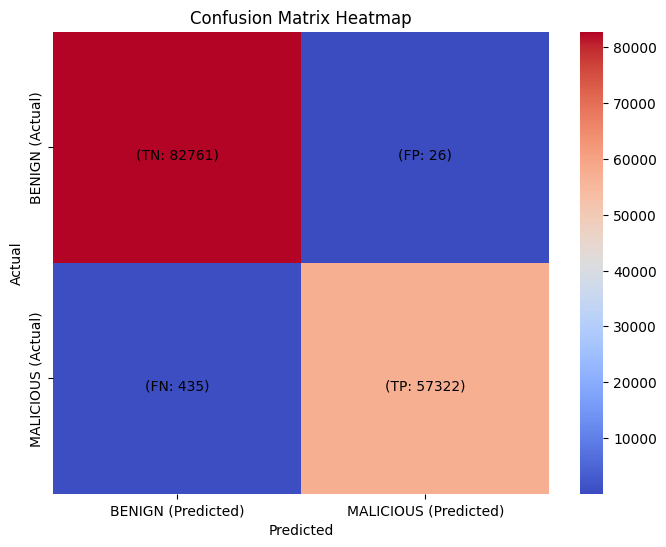

Classification Report:
              precision    recall  f1-score   support

      BENIGN       0.99      1.00      1.00     82787
   MALICIOUS       1.00      0.99      1.00     57757

    accuracy                           1.00    140544
   macro avg       1.00      1.00      1.00    140544
weighted avg       1.00      1.00      1.00    140544



In [18]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

import warnings
warnings.filterwarnings("ignore")

# day = 'Monday'
# day = 'Tuesday'
# day = 'Wednesday'
# day = 'Thursday'
day = 'Friday'
processed_filepath = './datasets/processed/'
data = pd.read_csv(processed_filepath + f'{day}.csv')
df = data.copy()
# df['Label'] = df['Label'].map(lambda x: 0 if x == "BENIGN" else 1)


print("Unikalne wartości w kolumnie 'Label':")
print(df['Label'].unique())
print(df['Label'].value_counts())

# df.columns = df.columns.str.replace(' ', '_')
# df.replace([np.inf, -np.inf], np.nan, inplace=True)
# df.dropna(inplace=True)

X = df.drop('Label', axis=1).values
y = df['Label'].values

# Normalizacja danych
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)  # Zakładamy, że X to Twoje dane wejściowe

# Podział na zestawy treningowe i testowe
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42, stratify=y)

# Budowa sieci encoder-decoder
input_dim = X_train.shape[1]

# Warstwa wejściowa
input_layer = Input(shape=(input_dim,))

# Encoder
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(32, activation='relu')(encoded) 

# Decoder
decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)

# Warstwa wyjściowa do klasyfikacji
output_layer = Dense(1, activation='sigmoid')(decoded)

# Model
model = Model(inputs=input_layer, outputs=output_layer)

start_time = time.time()
# Kompilacja modelu
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'Precision', 'Recall'])

# Trenowanie modelu
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))

# Ewaluacja modelu
y_pred_probs = model.predict(X_test)
y_pred_classes = (y_pred_probs >= 0.5).astype(int)

end_time = time.time() 
print("Work time: ", end_time - start_time, "s")

cm = confusion_matrix(y_test, y_pred_classes)
print("Confusion Matrix:")
print(cm)

# Wizualizacja macierzy konfuzji
plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm, annot=False, fmt='d', cmap='coolwarm', 
                 xticklabels=['BENIGN (Predicted)', 'MALICIOUS (Predicted)'], 
                 yticklabels=['BENIGN (Actual)', 'MALICIOUS (Actual)'])

labels = [[f'TN: {cm[0][0]}', f'FP: {cm[0][1]}'], 
          [f'FN: {cm[1][0]}', f'TP: {cm[1][1]}']]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.5, f'\n({labels[i][j]})', 
                color='Black', ha='center', va='center', fontsize=10)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_classes, target_names=['BENIGN', 'MALICIOUS']))

In [19]:
import numpy as np
import os

TN, FP = cm[0]
FN, TP = cm[1]

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

In [20]:
results_dir = './results/AE/'
os.makedirs(results_dir, exist_ok=True)
results_filepath = results_dir + f'AE_{day}_model_results.txt'

with open(results_filepath, 'w') as f:
    f.write("==========================================================================================\n")
    f.write("===\n")
    f.write(f"{results_filepath}\n")
    f.write("===\n")
    f.write(f"Czas uczenia: {end_time - start_time:.2f} s\n")
    f.write(f"Macierz konfuzji:\n")
    f.write(f"[[ True Negatives (TN): {cm[0][0]}   False Positives (FP): {cm[0][1]} ]\n")
    f.write(f" [ False Negatives (FN): {cm[1][0]}   True Positives (TP): {cm[1][1]} ]]\n\n")
    f.write(f"Accuracy: {accuracy:.2%}\n")
    f.write(f"Precision (dla klasy ATTACK): {precision:.2%}\n")
    f.write(f"Recall (dla klasy ATTACK): {recall:.2%}\n")
    f.write(f"F1-score: {f1_score:.2%}\n")
    f.write("==========================================================================================\n")

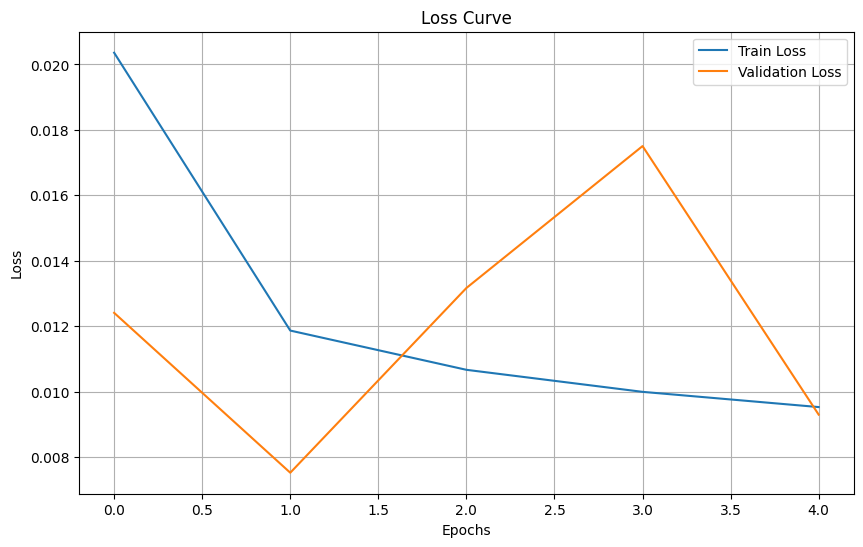

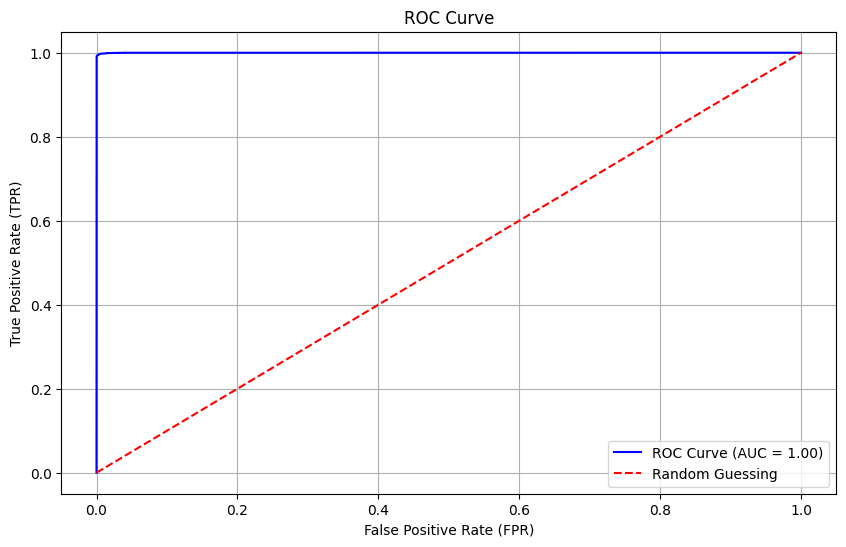

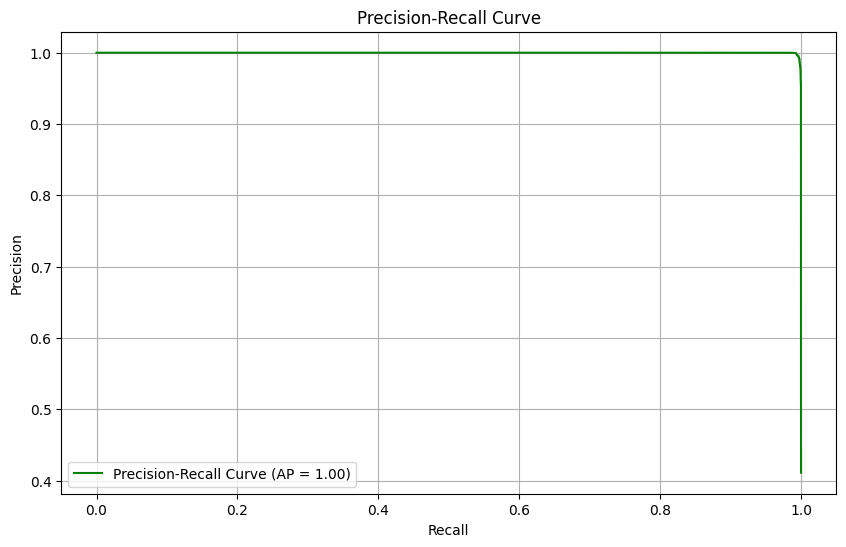

In [21]:
def make_loss_plot():
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()
    plt.show()

def make_roc_plot():
    from sklearn.metrics import roc_curve, auc

    fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing')
    plt.title('ROC Curve')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.legend()
    plt.grid()
    plt.show()

def make_precission_recall_plot():
    from sklearn.metrics import precision_recall_curve, average_precision_score

    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_probs)
    average_precision = average_precision_score(y_test, y_pred_probs)

    plt.figure(figsize=(10, 6))
    plt.plot(recall, precision, color='green', label=f'Precision-Recall Curve (AP = {average_precision:.2f})')
    plt.title('Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid()
    plt.show()


make_loss_plot()
make_roc_plot()
make_precission_recall_plot()